In [ ]:
import os, sys, json, time, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore", category=UserWarning)

print(f"tensorflow : {tf.__version__}")
print(f"keras      : {keras.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"gpu        : {gpus if gpus else 'NONE — switch Runtime > Change runtime type > T4 GPU'}")

tensorflow : 2.20.0
keras      : 3.13.2
gpu        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR    = Path("/content/drive/MyDrive/cse440_project")
SPLIT_DIR   = DATA_DIR / "splits"
REPR_DIR    = DATA_DIR / "representations"
FIG_DIR     = DATA_DIR / "figures" / "fabiha"
RESULTS_DIR = DATA_DIR / "results" / "fabiha"
UTILS_DIR   = DATA_DIR / "utils"

assert SPLIT_DIR.exists(), "shortcut not added to My Drive — see Mahir's setup message"
for d in (FIG_DIR, RESULTS_DIR, UTILS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"artifacts : {DATA_DIR}")
print(f"results   : {RESULTS_DIR}")
print(f"figures   : {FIG_DIR}")

Mounted at /content/drive
artifacts : /content/drive/MyDrive/cse440_project
results   : /content/drive/MyDrive/cse440_project/results/fabiha
figures   : /content/drive/MyDrive/cse440_project/figures/fabiha


In [ ]:
train = pd.read_parquet(SPLIT_DIR / "train.parquet")
val   = pd.read_parquet(SPLIT_DIR / "val.parquet")
test  = pd.read_parquet(SPLIT_DIR / "test.parquet")

with open(SPLIT_DIR / "label_map.json") as f:
    label_meta = json.load(f)

CLASS_NAMES = label_meta["classes"]
SUPERCLASS  = label_meta["superclass"]
NUM_CLASSES = label_meta["num_classes"]

X_train_seq = np.load(REPR_DIR / "seq_train.npy")
X_val_seq   = np.load(REPR_DIR / "seq_val.npy")
X_test_seq  = np.load(REPR_DIR / "seq_test.npy")

emb_glove = np.load(REPR_DIR / "emb_glove.npy")
emb_w2v   = np.load(REPR_DIR / "emb_word2vec.npy")

with open(REPR_DIR / "tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open(REPR_DIR / "repr_meta.json") as f:
    repr_meta = json.load(f)

y_train = train["label"].values
y_val   = val["label"].values
y_test  = test["label"].values

VOCAB_SIZE    = repr_meta["vocab_size"]
MAX_LEN       = repr_meta["max_len"]
EMBEDDING_DIM = repr_meta["embedding_dim"]

print(f"splits    : {train.shape} {val.shape} {test.shape}")
print(f"sequences : {X_train_seq.shape} {X_val_seq.shape} {X_test_seq.shape}")
print(f"embeddings: glove {emb_glove.shape}  word2vec {emb_w2v.shape}")
print(f"vocab     : {VOCAB_SIZE:,}   max_len: {MAX_LEN}   dim: {EMBEDDING_DIM}")
print(f"coverage  : word2vec {repr_meta['coverage_word2vec']:.1%}  "
      f"glove {repr_meta['coverage_glove']:.1%}")

splits    : (9249, 5) (1633, 5) (7262, 5)
sequences : (9249, 250) (1633, 250) (7262, 250)
embeddings: glove (20000, 50)  word2vec (20000, 50)
vocab     : 20,000   max_len: 250   dim: 50
coverage  : word2vec 100.0%  glove 87.3%


In [ ]:
print(f"shapes      : {train.shape} {val.shape} {test.shape}")
print(f"label counts: {train.label.value_counts().sort_index().tolist()}")
print(f"first clean : {train.text_clean.iloc[0][:80]!r}")
print(f"checksum tr : {pd.util.hash_pandas_object(train.text_clean).sum()}")
print(f"checksum te : {pd.util.hash_pandas_object(test.text_clean).sum()}")

EXPECTED_TR = 13885266476465583340
EXPECTED_TE = 259686901888230227
ok = (pd.util.hash_pandas_object(train.text_clean).sum() == EXPECTED_TR
      and pd.util.hash_pandas_object(test.text_clean).sum() == EXPECTED_TE)
print("\nchecksum match:", "PASS — cleared to train" if ok else "FAIL — do not train")

DATASET_CHECKSUM = int(EXPECTED_TR)

assert ok, ("checksum mismatch — the shared splits changed after Phase 1 was "
            "signed off. Do not train; message the team.")

shapes      : (9249, 5) (1633, 5) (7262, 5)
label counts: [394, 476, 472, 488, 467, 488, 484, 469, 488, 481, 493, 493, 485, 489, 488, 501, 451, 458, 382, 302]
first clean : 'yes say absolutey true fail mention fact lciii us new pin simms allow bite acces'
checksum tr : 13885266476465583340
checksum te : 259686901888230227

checksum match: PASS — cleared to train


In [ ]:
SEED = 42

SEQ_GRID = [
    {"name": "S1", "emb": "glove",    "units": 64,  "dropout": 0.3, "trainable_emb": False},
    {"name": "S2", "emb": "word2vec", "units": 64,  "dropout": 0.3, "trainable_emb": False},
    {"name": "S3", "emb": "word2vec", "units": 128, "dropout": 0.5, "trainable_emb": True},
]

BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS    = 30
PATIENCE      = 5
CLIPNORM      = 1.0
MONITOR       = "val_accuracy"
MONITOR_MODE  = "max"

EMB = {"glove": emb_glove, "word2vec": emb_w2v}

keras.utils.set_random_seed(SEED)

print(pd.DataFrame(SEQ_GRID).set_index("name").to_string())
print(f"\nbatch {BATCH_SIZE} | lr {LEARNING_RATE} | max_epochs {MAX_EPOCHS} | "
      f"patience {PATIENCE} | clipnorm {CLIPNORM} | monitor {MONITOR}")
print(f"runs to train: 2 architectures x 3 configs = 6, plus 2 ablation runs in section 3")

           emb  units  dropout  trainable_emb
name                                         
S1       glove     64      0.3          False
S2    word2vec     64      0.3          False
S3    word2vec    128      0.5           True

batch 64 | lr 0.001 | max_epochs 30 | patience 5 | clipnorm 1.0 | monitor val_accuracy
runs to train: 2 architectures x 3 configs = 6, plus 2 ablation runs in section 3


In [ ]:
%%writefile /content/drive/MyDrive/cse440_project/utils/evaluation.py
"""
utils/evaluation.py
CSE440 project — shared scoring module.

Owner: Fabiha. Used by all four notebooks so that every number in the final
comparison table is produced by the same code path.

The scoring contract (fixed — do not change without telling the team):

    1. accuracy
    2. macro-F1
    3. weighted-F1
    4. full sklearn classification report (per-class P / R / F1 / support)
    5. row-normalised confusion matrix
    6. within-family vs cross-family error split

Nothing in here imports TensorFlow, torch or transformers, so the classical
tier, the sequence tier and the BERT notebook can all use it unchanged.

Version history
---------------
v1.0  Initial contract.
v1.1  **Run schema changed; scoring did not.** `RUN_COLUMNS` went from 23 to 26
      columns: `params` was split into `n_params` and `hyperparams`, and `tier`
      and `dataset_checksum` were added. `evaluate_model`, `to_labels`,
      `family_error_split`, `per_class_table` and `top_confusions` are byte for
      byte unchanged, so runs logged under v1.0 and v1.1 were scored by the same
      code and are directly comparable. `log_run` gained warn-only schema
      validation and `print_contract` now reports the column count; neither
      computes a metric. If the report cites two version numbers, this is the
      only difference between them.

Install (once, from any notebook):

    DATA_DIR = Path("/content/drive/MyDrive/cse440_project")
    (DATA_DIR / "utils").mkdir(exist_ok=True)
    # drop evaluation.py and __init__.py in there

Use:

    import sys; sys.path.insert(0, "/content/drive/MyDrive/cse440_project")
    from utils import evaluation as ev

    meta = ev.load_label_meta(SPLIT_DIR)
    res  = ev.evaluate_model(y_true, y_pred,
                             class_names=meta["classes"],
                             superclass=meta["superclass"],
                             model_name="LSTM (S2)")
"""

from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

SCORING_CONTRACT_VERSION = "1.1"

CONTRACT = [
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "classification_report",
    "confusion_matrix_row_normalised",
    "within_vs_cross_family_error_split",
]

RUN_COLUMNS = [
    "run_id", "owner", "notebook", "tier", "model", "config",
    "embedding", "units", "dropout", "trainable_emb",
    "batch_size", "learning_rate", "epochs_run", "best_epoch",
    "n_params", "hyperparams",
    "val_loss", "val_accuracy", "val_macro_f1",
    "test_accuracy", "test_macro_f1", "test_weighted_f1",
    "train_time_s", "dataset_checksum", "timestamp", "notes",
]
.
TIERS = ("classical", "recurrent", "transformer")
NOTE_KINDS = ("required", "ablation")

__all__ = [
    "SCORING_CONTRACT_VERSION", "CONTRACT", "RUN_COLUMNS", "TIERS", "NOTE_KINDS",
    "print_contract", "load_label_meta", "to_labels",
    "evaluate_model", "family_error_split", "per_class_table",
    "top_confusions", "plot_confusion_matrix", "plot_per_class_f1",
    "log_run", "load_runs", "leaderboard", "compare_models",
    "save_result", "coverage_note",
]


def print_contract() -> None:
    """Print what this module guarantees to return. Useful as a sanity cell."""
    print(f"utils.evaluation — scoring contract v{SCORING_CONTRACT_VERSION}")
    for i, item in enumerate(CONTRACT, 1):
        print(f"  {i}. {item}")
    print(f"\nrun schema : {len(RUN_COLUMNS)} columns")
    print(f"tiers      : {', '.join(TIERS)}")
    print(f"note kinds : {', '.join(NOTE_KINDS)}")


def load_label_meta(split_dir) -> dict:
    """Read label_map.json written by 01_phase1_mahir.ipynb.

    Returns a dict with keys: classes (list[str]), superclass (dict name->family),
    num_classes (int), families (sorted list of family names).
    """
    path = Path(split_dir) / "label_map.json"
    with open(path) as f:
        meta = json.load(f)
    meta["families"] = sorted(set(meta["superclass"].values()))
    return meta


def to_labels(y) -> np.ndarray:
    """Accept integer labels, one-hot rows, or softmax probabilities.

    Anything 2-D with more than one column is collapsed with argmax, so the
    same call works for sklearn `.predict()` output and Keras `.predict()`
    output without the caller remembering which is which.
    """
    y = np.asarray(y)
    if y.ndim == 2 and y.shape[1] > 1:
        y = y.argmax(axis=1)
    return y.ravel().astype(int)

def family_error_split(y_true, y_pred, class_names, superclass) -> dict:
    """Split misclassifications into within-family and cross-family.

    The 20 newsgroups cluster into `comp.*`, `rec.*`, `sci.*`, `talk.*` plus
    three loners. Confusing two `comp.*` groups is a different kind of failure
    from confusing `comp.graphics` with `soc.religion.christian`, and reporting
    only accuracy hides that difference entirely. Two models can share an
    accuracy figure and split their errors completely differently.

    Returns counts, rates, and a per-family breakdown DataFrame.
    """
    y_true = to_labels(y_true)
    y_pred = to_labels(y_pred)

    fam_of_idx = np.array([superclass[c] for c in class_names])
    true_fam = fam_of_idx[y_true]
    pred_fam = fam_of_idx[y_pred]

    wrong = y_true != y_pred
    n_err = int(wrong.sum())
    within = int((wrong & (true_fam == pred_fam)).sum())
    cross = n_err - within

    rows = []
    for fam in sorted(set(fam_of_idx)):
        m = true_fam == fam
        n = int(m.sum())
        w = int((wrong & m).sum())
        wi = int((wrong & m & (pred_fam == fam)).sum())
        rows.append({
            "family": fam,
            "support": n,
            "errors": w,
            "error_rate": w / n if n else 0.0,
            "within_family": wi,
            "cross_family": w - wi,
            "pct_of_errors_within": (wi / w) if w else 0.0,
        })

    return {
        "n_errors": n_err,
        "within_family": within,
        "cross_family": cross,
        "within_share": within / n_err if n_err else 0.0,
        "cross_share": cross / n_err if n_err else 0.0,
        "family_confusability": within / len(y_true),
        "per_family": pd.DataFrame(rows).set_index("family").round(4),
    }

def evaluate_model(
    y_true,
    y_pred,
    class_names,
    superclass=None,
    model_name: str = "model",
    split: str = "test",
    digits: int = 4,
    verbose: bool = True,
) -> dict:
    """Score one model against the full contract.

    Returns a dict with:
        model, split, accuracy, macro_f1, weighted_f1,
        report_str, report_df, cm, cm_norm, per_class, family (or None)
    """
    y_true = to_labels(y_true)
    y_pred = to_labels(y_pred)
    labels = list(range(len(class_names)))

    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    weighted = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)

    report_str = classification_report(
        y_true, y_pred, labels=labels, target_names=class_names,
        digits=digits, zero_division=0,
    )
    report_df = pd.DataFrame(
        classification_report(
            y_true, y_pred, labels=labels, target_names=class_names,
            output_dict=True, zero_division=0,
        )
    ).T

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    with np.errstate(invalid="ignore", divide="ignore"):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    out = {
        "model": model_name,
        "split": split,
        "accuracy": float(acc),
        "macro_f1": float(macro),
        "weighted_f1": float(weighted),
        "report_str": report_str,
        "report_df": report_df,
        "cm": cm,
        "cm_norm": cm_norm,
        "per_class": per_class_table(y_true, y_pred, class_names, superclass),
        "family": None,
    }

    if superclass is not None:
        out["family"] = family_error_split(y_true, y_pred, class_names, superclass)

    if verbose:
        print(f"{model_name}  [{split}]")
        print(f"  accuracy    : {acc:.4f}")
        print(f"  macro-F1    : {macro:.4f}")
        print(f"  weighted-F1 : {weighted:.4f}")
        if out["family"] is not None:
            f = out["family"]
            print(f"  errors      : {f['n_errors']:,} "
                  f"({f['within_family']:,} within-family = {f['within_share']:.1%}, "
                  f"{f['cross_family']:,} cross-family = {f['cross_share']:.1%})")
    return out


def per_class_table(y_true, y_pred, class_names, superclass=None) -> pd.DataFrame:
    """Per-class precision / recall / F1 / support, sorted worst F1 first."""
    y_true = to_labels(y_true)
    y_pred = to_labels(y_pred)
    labels = list(range(len(class_names)))
    p, r, f, s = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    df = pd.DataFrame(
        {"precision": p, "recall": r, "f1": f, "support": s}, index=class_names
    )
    if superclass is not None:
        df.insert(0, "family", [superclass[c] for c in class_names])
    return df.sort_values("f1").round(4)


def top_confusions(y_true, y_pred, class_names, superclass=None, k: int = 12) -> pd.DataFrame:
    """The k most frequent (true -> predicted) mistakes, off-diagonal only."""
    y_true = to_labels(y_true)
    y_pred = to_labels(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    support = cm.sum(axis=1)

    rows = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i == j or cm[i, j] == 0:
                continue
            row = {
                "true": class_names[i],
                "predicted": class_names[j],
                "count": int(cm[i, j]),
                "pct_of_true_class": cm[i, j] / support[i] if support[i] else 0.0,
            }
            if superclass is not None:
                row["same_family"] = superclass[class_names[i]] == superclass[class_names[j]]
            rows.append(row)

    return (pd.DataFrame(rows)
            .sort_values("count", ascending=False)
            .head(k)
            .reset_index(drop=True)
            .round(4))


def plot_confusion_matrix(
    result_or_cm,
    class_names=None,
    title: str = "Confusion matrix (row-normalised)",
    save_path=None,
    figsize=(11, 9),
    annotate: bool = False,
    cmap: str = "viridis",
):
    """Heatmap of the row-normalised confusion matrix.

    Accepts either the dict returned by `evaluate_model` or a raw matrix.
    Row-normalised means each row sums to 1, so a bright off-diagonal cell is
    a class losing a large *share* of its documents, not just a big class.
    """
    if isinstance(result_or_cm, dict):
        cm_norm = result_or_cm["cm_norm"]
        class_names = class_names or [str(i) for i in range(cm_norm.shape[0])]
        title = f"{result_or_cm['model']} — {title}"
    else:
        cm_norm = np.asarray(result_or_cm)
        class_names = class_names or [str(i) for i in range(cm_norm.shape[0])]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="share of true class")

    if annotate:
        for i in range(cm_norm.shape[0]):
            for j in range(cm_norm.shape[1]):
                v = cm_norm[i, j]
                if v >= 0.01:
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if v < 0.6 else "black")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig, ax


def plot_per_class_f1(result, save_path=None, figsize=(9, 7)):
    """Horizontal bar of per-class F1, coloured by family, worst at the bottom."""
    pc = result["per_class"].sort_values("f1")
    fig, ax = plt.subplots(figsize=figsize)

    if "family" in pc.columns:
        fams = sorted(pc["family"].unique())
        palette = dict(zip(fams, plt.cm.tab10.colors))
        colors = [palette[f] for f in pc["family"]]
        handles = [plt.Rectangle((0, 0), 1, 1, color=palette[f]) for f in fams]
        ax.legend(handles, fams, fontsize=8, loc="lower right", title="family")
    else:
        colors = None

    ax.barh(pc.index, pc["f1"], color=colors)
    ax.set_xlabel("F1")
    ax.set_xlim(0, 1)
    ax.set_title(f"{result['model']} — per-class F1 ({result['split']})")
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig, ax


def log_run(csv_path, record: dict, echo: bool = True) -> pd.DataFrame:
    """Append one run to a CSV, replacing any earlier row with the same run_id.

    Written to be crash-safe: the file is rewritten in full every call, so a
    Colab disconnect halfway through a grid never leaves a half-row behind.
    """
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    record = dict(record)
    record.setdefault("timestamp", time.strftime("%Y-%m-%d %H:%M:%S"))
    record.setdefault("notes", "required")

    tier = record.get("tier")
    if tier is not None and tier not in TIERS:
        print(f"warn: tier {tier!r} is not one of {TIERS} — the merged table "
              "groups on this column")
    kind = str(record.get("notes", "")).split(" ")[0]
    if kind and kind not in NOTE_KINDS:
        print(f"warn: notes should start with one of {NOTE_KINDS}, got {kind!r}")
    if "params" in record:
        print("warn: `params` was retired in contract v1.1 — use `n_params` "
              "for the count and `hyperparams` for the JSON")

    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        df = pd.DataFrame()

    if "run_id" in record and "run_id" in df.columns:
        df = df[df["run_id"] != record["run_id"]]

    df = pd.concat([df, pd.DataFrame([record])], ignore_index=True)

    ordered = [c for c in RUN_COLUMNS if c in df.columns]
    extra = [c for c in df.columns if c not in ordered]
    df = df[ordered + extra]

    df.to_csv(csv_path, index=False)
    if echo:
        print(f"logged {record.get('run_id', '?')} -> {csv_path.name} "
              f"({len(df)} rows)")
    return df


def load_runs(*csv_paths) -> pd.DataFrame:
    """Concatenate one or more runs_<name>.csv files into a single table."""
    frames = []
    for p in csv_paths:
        p = Path(p)
        if p.exists():
            frames.append(pd.read_csv(p))
        else:
            print(f"warn: missing {p}")
    if not frames:
        return pd.DataFrame(columns=RUN_COLUMNS)
    return pd.concat(frames, ignore_index=True)


def leaderboard(runs: pd.DataFrame, by: str = "val_accuracy", top: int = None) -> pd.DataFrame:
    """Sort a runs table by a metric, best first."""
    if by not in runs.columns:
        raise KeyError(f"{by} not in runs table; have {list(runs.columns)}")
    out = runs.sort_values(by, ascending=False).reset_index(drop=True)
    return out.head(top) if top else out


def compare_models(results: dict, superclass_split: bool = True) -> pd.DataFrame:
    """Build the consolidated comparison table from several `evaluate_model` dicts.

    `results` maps a display name to a result dict. This is what section 3.9
    of the report needs: one row per model, same six columns for everybody.
    """
    rows = []
    for name, r in results.items():
        row = {
            "model": name,
            "accuracy": r["accuracy"],
            "macro_f1": r["macro_f1"],
            "weighted_f1": r["weighted_f1"],
        }
        if superclass_split and r.get("family"):
            f = r["family"]
            row["errors"] = f["n_errors"]
            row["within_family_%"] = 100 * f["within_share"]
            row["cross_family_%"] = 100 * f["cross_share"]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True).round(4)


def save_result(result: dict, out_dir, stem: str) -> Path:
    """Persist the JSON-safe parts of a result so the report can be written
    without re-running the notebook."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        "contract_version": SCORING_CONTRACT_VERSION,
        "model": result["model"],
        "split": result["split"],
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "weighted_f1": result["weighted_f1"],
        "confusion_matrix": result["cm"].tolist(),
        "per_class": result["per_class"].reset_index().to_dict(orient="records"),
    }
    if result.get("family"):
        f = result["family"]
        payload["family_split"] = {
            "n_errors": f["n_errors"],
            "within_family": f["within_family"],
            "cross_family": f["cross_family"],
            "within_share": f["within_share"],
            "cross_share": f["cross_share"],
            "per_family": f["per_family"].reset_index().to_dict(orient="records"),
        }
    path = out_dir / f"{stem}.json"
    with open(path, "w") as fh:
        json.dump(payload, fh, indent=2)
    return path


def coverage_note(seq_array, pad_value: int = 0) -> dict:
    """How much of the corpus the sequence models actually saw.

    Any document that filled every one of the MAX_LEN slots was truncated, and
    whatever came after the cut is signal no sequence model in this project has
    ever been shown. This is the standing caveat on the whole RNN tier.
    """
    seq = np.asarray(seq_array)
    lengths = (seq != pad_value).sum(axis=1)
    full = int((lengths >= seq.shape[1]).sum())
    return {
        "max_len": int(seq.shape[1]),
        "n_docs": int(seq.shape[0]),
        "truncated_docs": full,
        "truncated_share": full / seq.shape[0],
        "mean_tokens_used": float(lengths.mean()),
        "median_tokens_used": float(np.median(lengths)),
    }

Overwriting /content/drive/MyDrive/cse440_project/utils/evaluation.py


In [ ]:
%%writefile /content/drive/MyDrive/cse440_project/utils/__init__.py
"""CSE440 shared helpers. See evaluation.py for the scoring contract."""

from . import evaluation  # noqa: F401

__all__ = ["evaluation"]

Overwriting /content/drive/MyDrive/cse440_project/utils/__init__.py


In [ ]:
sys.path.insert(0, str(DATA_DIR))

import importlib
import utils.evaluation as ev
importlib.reload(ev)

ev.print_contract()

meta = ev.load_label_meta(SPLIT_DIR)
print(f"\nclasses  : {meta['num_classes']}")
print(f"families : {meta['families']}")

utils.evaluation — scoring contract v1.1
  1. accuracy
  2. macro_f1
  3. weighted_f1
  4. classification_report
  5. confusion_matrix_row_normalised
  6. within_vs_cross_family_error_split

run schema : 26 columns
tiers      : classical, recurrent, transformer
note kinds : required, ablation

classes  : 20
families : ['alt', 'comp', 'misc', 'rec', 'sci', 'soc', 'talk']


In [ ]:
for name, arr in [("train", X_train_seq), ("val", X_val_seq), ("test", X_test_seq)]:
    c = ev.coverage_note(arr)
    print(f"{name:5s} truncated {c['truncated_docs']:5,}/{c['n_docs']:,} "
          f"= {c['truncated_share']:5.1%}   median tokens used {c['median_tokens_used']:.0f}")

train truncated   544/9,249 =  5.9%   median tokens used 43
val   truncated   117/1,633 =  7.2%   median tokens used 44
test  truncated   419/7,262 =  5.8%   median tokens used 42


In [ ]:
def build_sequence_model(emb_matrix, units, dropout, bidirectional=False,
                         trainable_emb=False, cell=LSTM, num_classes=NUM_CLASSES):
    vocab_size, emb_dim = emb_matrix.shape

    inp = Input(shape=(MAX_LEN,), dtype="int32", name="tokens")
    x = Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        mask_zero=True,
        trainable=trainable_emb,
        name="embedding",
    )(inp)

    rnn = cell(units, dropout=dropout, recurrent_dropout=0.0, name="recurrent")
    x = Bidirectional(rnn, name="bidirectional")(x) if bidirectional else rnn(x)

    x = Dropout(dropout, name="head_dropout")(x)
    out = Dense(num_classes, activation="softmax", name="softmax")(x)

    model = Model(inp, out, name=("bi_" if bidirectional else "") + cell.__name__.lower())
    model.get_layer("embedding").set_weights([emb_matrix])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
RUNS_CSV = RESULTS_DIR / "runs_fabiha.csv"
WEIGHT_DIR = RESULTS_DIR / "weights"
WEIGHT_DIR.mkdir(parents=True, exist_ok=True)

HISTORIES = {}
MODELS = {}

def train_one_run(arch, cfg, X_tr=None, y_tr=None, X_va=None, y_va=None,
                  tag=None, notes="", log=True):
    X_tr = X_train_seq if X_tr is None else X_tr
    y_tr = y_train     if y_tr is None else y_tr
    X_va = X_val_seq   if X_va is None else X_va
    y_va = y_val       if y_va is None else y_va

    run_id = tag or f"{arch}_{cfg['name']}"
    keras.utils.set_random_seed(SEED)

    model = build_sequence_model(
        emb_matrix=cfg.get("emb_matrix", EMB[cfg["emb"]]),
        units=cfg["units"],
        dropout=cfg["dropout"],
        bidirectional=(arch == "Bi-LSTM"),
        trainable_emb=cfg["trainable_emb"],
    )

    stopper = EarlyStopping(monitor=MONITOR, mode=MONITOR_MODE, patience=PATIENCE,
                            restore_best_weights=True, verbose=1)

    print(f"\n{'='*70}\n{run_id}  |  {arch}  |  emb={cfg['emb']}  units={cfg['units']}  "
          f"dropout={cfg['dropout']}  trainable_emb={cfg['trainable_emb']}\n{'='*70}")

    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[stopper],
        verbose=2,
    )
    elapsed = time.time() - t0

    best_epoch = int(np.argmax(hist.history[MONITOR])) + 1
    val_probs = model.predict(X_va, batch_size=256, verbose=0)
    res = ev.evaluate_model(y_va, val_probs, CLASS_NAMES, SUPERCLASS,
                            model_name=run_id, split="val", verbose=False)

    record = {
        "run_id": run_id, "owner": "fabiha", "notebook": "04_lstm_fabiha.ipynb",
        "model": arch, "config": cfg["name"], "embedding": cfg["emb"],
        "units": cfg["units"], "dropout": cfg["dropout"],
        "trainable_emb": cfg["trainable_emb"],
        "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "epochs_run": len(hist.history["loss"]), "best_epoch": best_epoch,
        "params": int(model.count_params()),
        "val_loss": float(min(hist.history["val_loss"])),
        "val_accuracy": float(res["accuracy"]),
        "val_macro_f1": float(res["macro_f1"]),
        "train_time_s": round(elapsed, 1),
        "notes": notes,
    }

    HISTORIES[run_id] = hist.history
    MODELS[run_id] = model
    model.save_weights(str(WEIGHT_DIR / f"{run_id}.weights.h5"))
    if log:
        ev.log_run(RUNS_CSV, record)

    print(f"\n{run_id}: val acc {record['val_accuracy']:.4f} | "
          f"val macro-F1 {record['val_macro_f1']:.4f} | "
          f"best epoch {best_epoch}/{record['epochs_run']} | {elapsed:.0f}s")
    return model, record

Architecture check before committing GPU time to eight runs.

In [ ]:
_probe = build_sequence_model(emb_glove, units=64, dropout=0.3, bidirectional=False)
_probe.summary()
print()
_probe_bi = build_sequence_model(emb_glove, units=64, dropout=0.3, bidirectional=True)
print(f"LSTM    params: {_probe.count_params():,}")
print(f"Bi-LSTM params: {_probe_bi.count_params():,}")
print(f"embedding trainable: {_probe.get_layer('embedding').trainable}")
del _probe, _probe_bi
keras.backend.clear_session()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 250)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 50)   │  1,000,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ tokens[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recurrent (LSTM)    │ (None, 64)        │     29,440 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 64)        │          0 │ recurrent[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 20)        │      1,300 │ head_dropout[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,030,740 (3.93 MB)

 Trainable params: 30,740 (120.08 KB)

 Non-trainable params: 1,000,000 (3.81 MB)


LSTM    params: 1,030,740
Bi-LSTM params: 1,061,460
embedding trainable: False


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = repr_meta["max_vocab"]

tok_light = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok_light.fit_on_texts(train["text_light"])

def pad_light(texts):
    return pad_sequences(tok_light.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding="post", truncating="post")

X_train_light = pad_light(train["text_light"])
X_val_light   = pad_light(val["text_light"])

vocab_light = min(MAX_VOCAB, len(tok_light.word_index) + 1)

print(f"light vocabulary seen : {len(tok_light.word_index):,}")
print(f"clean vocabulary seen : {len(tokenizer.word_index):,}")
print(f"light vocab_size used : {vocab_light:,}")

light vocabulary seen : 60,498
clean vocabulary seen : 49,395
light vocab_size used : 20,000


In [ ]:
glove_path = DATA_DIR / "glove.6B.50d.txt"
glove = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        glove[parts[0]] = np.asarray(parts[1:], dtype="float32")

emb_glove_light = np.zeros((vocab_light, EMBEDDING_DIM), dtype="float32")
hits = 0
for word, idx in tok_light.word_index.items():
    if idx >= vocab_light:
        continue
    vec = glove.get(word)
    if vec is not None:
        emb_glove_light[idx] = vec
        hits += 1

cov_light = hits / (vocab_light - 1)
print(f"glove coverage on light vocab : {hits:,}/{vocab_light-1:,} = {cov_light:.1%}")
print(f"glove coverage on clean vocab : {repr_meta['coverage_glove']:.1%}")

del glove

glove coverage on light vocab : 18,665/19,999 = 93.3%
glove coverage on clean vocab : 87.3%


In [ ]:
ABL_CFG_CLEAN = {**SEQ_GRID[0], "name": "ABL-clean"}
ABL_CFG_LIGHT = {**SEQ_GRID[0], "name": "ABL-light", "emb_matrix": emb_glove_light}

_, abl_clean = train_one_run("LSTM", ABL_CFG_CLEAN, tag="ABL_clean",
                             notes="preprocessing ablation: text_clean (full strategy)")

_, abl_light = train_one_run("LSTM", ABL_CFG_LIGHT,
                             X_tr=X_train_light, X_va=X_val_light,
                             tag="ABL_light",
                             notes="preprocessing ablation: text_light")


ABL_clean  |  LSTM  |  emb=glove  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 10s - 68ms/step - accuracy: 0.1386 - loss: 2.7279 - val_accuracy: 0.2535 - val_loss: 2.2291
Epoch 2/30
145/145 - 2s - 15ms/step - accuracy: 0.2691 - loss: 2.2031 - val_accuracy: 0.3515 - val_loss: 1.9320
Epoch 3/30
145/145 - 2s - 14ms/step - accuracy: 0.3184 - loss: 2.0360 - val_accuracy: 0.4115 - val_loss: 1.7807
Epoch 4/30
145/145 - 2s - 14ms/step - accuracy: 0.3723 - loss: 1.9053 - val_accuracy: 0.4207 - val_loss: 1.7194
Epoch 5/30
145/145 - 4s - 25ms/step - accuracy: 0.3969 - loss: 1.8196 - val_accuracy: 0.4666 - val_loss: 1.6172
Epoch 6/30
145/145 - 2s - 16ms/step - accuracy: 0.4234 - loss: 1.7522 - val_accuracy: 0.4905 - val_loss: 1.5771
Epoch 7/30
145/145 - 2s - 14ms/step - accuracy: 0.4479 - loss: 1.6869 - val_accuracy: 0.4985 - val_loss: 1.5367
Epoch 8/30
145/145 - 2s - 14ms/step - accuracy: 0.4606 - loss: 1.6415 - val_accuracy: 0.5144 - val_loss: 1.4836
Epoch 9/30
145/145 - 2s -

In [ ]:
abl = pd.DataFrame([abl_clean, abl_light])[
    ["run_id", "val_accuracy", "val_macro_f1", "best_epoch", "epochs_run", "train_time_s"]
].set_index("run_id").round(4)

delta = abl_clean["val_accuracy"] - abl_light["val_accuracy"]
print(abl.to_string())
print(f"\nfull-strategy advantage on validation accuracy: {delta:+.4f} "
      f"({100*delta:+.2f} pp)")

           val_accuracy  val_macro_f1  best_epoch  epochs_run  train_time_s
run_id                                                                     
ABL_clean        0.6320        0.6219          30          30          79.5
ABL_light        0.6099        0.5889          30          30          73.3

full-strategy advantage on validation accuracy: +0.0220 (+2.20 pp)


### 9.3 LSTM, three configurations

In [ ]:
lstm_records = []
for cfg in SEQ_GRID:
    _, rec = train_one_run("LSTM", cfg)
    lstm_records.append(rec)


LSTM_S1  |  LSTM  |  emb=glove  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 5s - 35ms/step - accuracy: 0.1386 - loss: 2.7279 - val_accuracy: 0.2535 - val_loss: 2.2282
Epoch 2/30
145/145 - 2s - 14ms/step - accuracy: 0.2651 - loss: 2.1999 - val_accuracy: 0.3442 - val_loss: 1.9427
Epoch 3/30
145/145 - 2s - 14ms/step - accuracy: 0.3197 - loss: 2.0333 - val_accuracy: 0.3956 - val_loss: 1.8051
Epoch 4/30
145/145 - 2s - 14ms/step - accuracy: 0.3651 - loss: 1.9107 - val_accuracy: 0.4262 - val_loss: 1.7201
Epoch 5/30
145/145 - 2s - 14ms/step - accuracy: 0.3938 - loss: 1.8180 - val_accuracy: 0.4532 - val_loss: 1.6251
Epoch 6/30
145/145 - 3s - 18ms/step - accuracy: 0.4205 - loss: 1.7503 - val_accuracy: 0.4856 - val_loss: 1.5796
Epoch 7/30
145/145 - 5s - 32ms/step - accuracy: 0.4428 - loss: 1.6990 - val_accuracy: 0.4917 - val_loss: 1.5344
Epoch 8/30
145/145 - 2s - 14ms/step - accuracy: 0.4584 - loss: 1.6529 - val_accuracy: 0.5113 - val_loss: 1.4778
Epoch 9/30
145/145 - 2s - 14

logged LSTM_S1 -> runs_fabiha.csv (3 rows)

LSTM_S1: val acc 0.6246 | val macro-F1 0.6120 | best epoch 30/30 | 76s

LSTM_S2  |  LSTM  |  emb=word2vec  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 4s - 26ms/step - accuracy: 0.1857 - loss: 2.5682 - val_accuracy: 0.3448 - val_loss: 1.9582
Epoch 2/30
145/145 - 2s - 16ms/step - accuracy: 0.3280 - loss: 1.9931 - val_accuracy: 0.4274 - val_loss: 1.6773
Epoch 3/30
145/145 - 3s - 22ms/step - accuracy: 0.3905 - loss: 1.7994 - val_accuracy: 0.4421 - val_loss: 1.5818
Epoch 4/30
145/145 - 2s - 15ms/step - accuracy: 0.4192 - loss: 1.7094 - val_accuracy: 0.4709 - val_loss: 1.5119
Epoch 5/30
145/145 - 2s - 15ms/step - accuracy: 0.4419 - loss: 1.6270 - val_accuracy: 0.5126 - val_loss: 1.4334
Epoch 6/30
145/145 - 2s - 14ms/step - accuracy: 0.4612 - loss: 1.5719 - val_accuracy: 0.5254 - val_loss: 1.3928
Epoch 7/30
145/145 - 2s - 14ms/step - accuracy: 0.4733 - loss: 1.5261 - val_accuracy: 0.5383 - val_loss: 1.3628
Epoch 8/30
145/145 - 2

logged LSTM_S2 -> runs_fabiha.csv (4 rows)

LSTM_S2: val acc 0.6301 | val macro-F1 0.6094 | best epoch 28/30 | 79s

LSTM_S3  |  LSTM  |  emb=word2vec  units=128  dropout=0.5  trainable_emb=True
Epoch 1/30
145/145 - 4s - 30ms/step - accuracy: 0.1767 - loss: 2.5667 - val_accuracy: 0.3417 - val_loss: 1.8597
Epoch 2/30
145/145 - 2s - 15ms/step - accuracy: 0.3148 - loss: 2.0521 - val_accuracy: 0.3962 - val_loss: 1.6985
Epoch 3/30
145/145 - 3s - 18ms/step - accuracy: 0.3644 - loss: 1.8723 - val_accuracy: 0.4550 - val_loss: 1.5535
Epoch 4/30
145/145 - 3s - 22ms/step - accuracy: 0.4061 - loss: 1.7507 - val_accuracy: 0.5089 - val_loss: 1.4638
Epoch 5/30
145/145 - 2s - 16ms/step - accuracy: 0.4337 - loss: 1.6617 - val_accuracy: 0.5181 - val_loss: 1.3990
Epoch 6/30
145/145 - 2s - 15ms/step - accuracy: 0.4644 - loss: 1.5793 - val_accuracy: 0.5340 - val_loss: 1.3520
Epoch 7/30
145/145 - 2s - 15ms/step - accuracy: 0.4891 - loss: 1.5070 - val_accuracy: 0.5591 - val_loss: 1.3016
Epoch 8/30
145/145 - 2

In [ ]:
bilstm_records = []
for cfg in SEQ_GRID:
    _, rec = train_one_run("Bi-LSTM", cfg)
    bilstm_records.append(rec)


Bi-LSTM_S1  |  Bi-LSTM  |  emb=glove  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 6s - 42ms/step - accuracy: 0.2012 - loss: 2.5279 - val_accuracy: 0.3521 - val_loss: 1.9114
Epoch 2/30
145/145 - 3s - 23ms/step - accuracy: 0.3513 - loss: 1.9302 - val_accuracy: 0.4274 - val_loss: 1.6758
Epoch 3/30
145/145 - 4s - 31ms/step - accuracy: 0.4123 - loss: 1.7323 - val_accuracy: 0.4495 - val_loss: 1.5909
Epoch 4/30
145/145 - 4s - 25ms/step - accuracy: 0.4474 - loss: 1.6258 - val_accuracy: 0.4807 - val_loss: 1.5066
Epoch 5/30
145/145 - 3s - 23ms/step - accuracy: 0.4723 - loss: 1.5552 - val_accuracy: 0.5083 - val_loss: 1.4495
Epoch 6/30
145/145 - 3s - 23ms/step - accuracy: 0.5014 - loss: 1.4927 - val_accuracy: 0.5364 - val_loss: 1.3750
Epoch 7/30
145/145 - 5s - 31ms/step - accuracy: 0.5207 - loss: 1.4343 - val_accuracy: 0.5334 - val_loss: 1.3828
Epoch 8/30
145/145 - 3s - 23ms/step - accuracy: 0.5402 - loss: 1.3936 - val_accuracy: 0.5579 - val_loss: 1.3205
Epoch 9/30
145/145 - 3

In [ ]:
runs = pd.read_csv(RUNS_CSV)
grid_runs = runs[~runs.run_id.str.startswith("ABL")].copy()

tune_table = grid_runs[[
    "model", "config", "embedding", "units", "dropout", "trainable_emb",
    "params", "epochs_run", "best_epoch", "val_loss", "val_accuracy",
    "val_macro_f1", "train_time_s",
]].sort_values(["model", "config"]).reset_index(drop=True).round(4)

print(tune_table.to_string(index=False))

best_lstm = grid_runs[grid_runs.model == "LSTM"].sort_values("val_accuracy").iloc[-1]
best_bi   = grid_runs[grid_runs.model == "Bi-LSTM"].sort_values("val_accuracy").iloc[-1]
print(f"\nbest LSTM    : {best_lstm.run_id}  val acc {best_lstm.val_accuracy:.4f}")
print(f"best Bi-LSTM : {best_bi.run_id}  val acc {best_bi.val_accuracy:.4f}")

  model config embedding  units  dropout  trainable_emb  params  epochs_run  best_epoch  val_loss  val_accuracy  val_macro_f1  train_time_s
Bi-LSTM     S1     glove     64      0.3          False 1061460          30          28    1.1252        0.6522        0.6378         113.9
Bi-LSTM     S2  word2vec     64      0.3          False 1061460          26          21    1.1501        0.6320        0.6130          98.8
Bi-LSTM     S3  word2vec    128      0.5           True 1188436          25          20    0.9850        0.7397        0.7283         104.6
   LSTM     S1     glove     64      0.3          False 1030740          30          30    1.1849        0.6246        0.6120          76.1
   LSTM     S2  word2vec     64      0.3          False 1030740          30          28    1.1583        0.6301        0.6094          78.6
   LSTM     S3  word2vec    128      0.5           True 1094228          30          28    0.9789        0.7250        0.7122          78.9

best LSTM    : LSTM

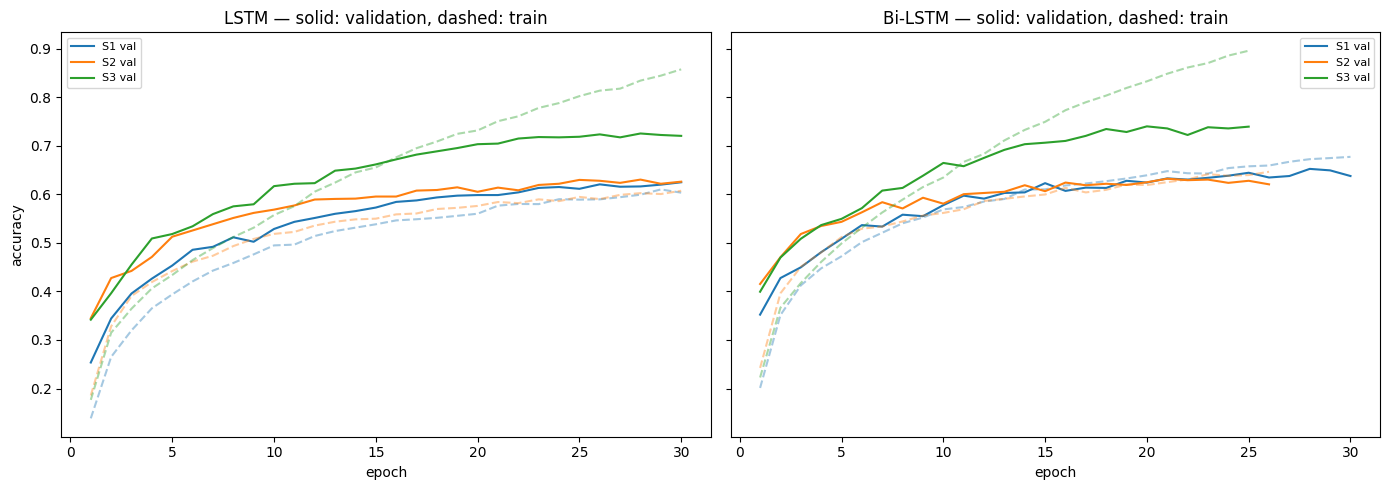

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, arch in zip(axes, ["LSTM", "Bi-LSTM"]):
    for cfg in SEQ_GRID:
        rid = f"{arch}_{cfg['name']}"
        h = HISTORIES.get(rid)
        if h is None:
            continue
        ep = range(1, len(h["accuracy"]) + 1)
        line, = ax.plot(ep, h["val_accuracy"], label=f"{cfg['name']} val")
        ax.plot(ep, h["accuracy"], ls="--", alpha=0.4, color=line.get_color())
    ax.set_title(f"{arch} — solid: validation, dashed: train")
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)

axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_training_curves.png", dpi=150)
plt.show()

In [ ]:
contrast = grid_runs[grid_runs.config.isin(["S1", "S2"])].pivot_table(
    index="model", columns="config", values=["val_accuracy", "val_macro_f1"]
).round(4)
contrast[("val_accuracy", "S2-S1")] = (contrast[("val_accuracy", "S2")]
                                       - contrast[("val_accuracy", "S1")]).round(4)
contrast[("val_macro_f1", "S2-S1")] = (contrast[("val_macro_f1", "S2")]
                                       - contrast[("val_macro_f1", "S1")]).round(4)
print(contrast.to_string())

zero_glove = int((emb_glove.sum(axis=1) == 0).sum())
zero_w2v   = int((emb_w2v.sum(axis=1) == 0).sum())
print(f"\ndead rows in the embedding matrix — glove {zero_glove:,}, word2vec {zero_w2v:,}")
print(f"vocabulary coverage           — glove {repr_meta['coverage_glove']:.1%}, "
      f"word2vec {repr_meta['coverage_word2vec']:.1%}")

        val_accuracy         val_macro_f1         val_accuracy val_macro_f1
config            S1      S2           S1      S2        S2-S1        S2-S1
model                                                                      
Bi-LSTM       0.6522  0.6320       0.6378  0.6130      -0.0202      -0.0248
LSTM          0.6246  0.6301       0.6120  0.6094       0.0055      -0.0026

dead rows in the embedding matrix — glove 2,536, word2vec 2
vocabulary coverage           — glove 87.3%, word2vec 100.0%


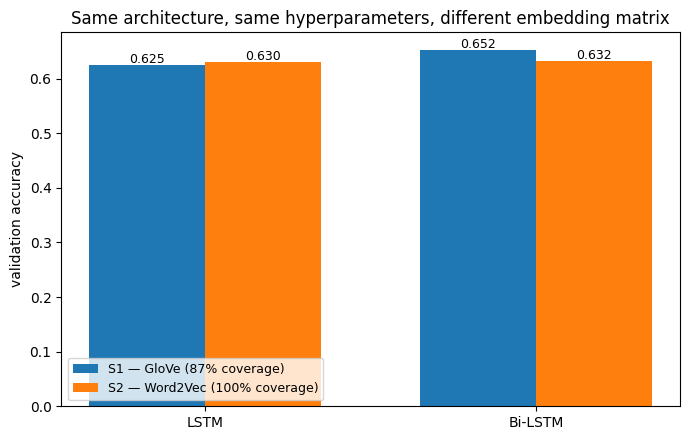

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
w = 0.35
models = ["LSTM", "Bi-LSTM"]
s1 = [grid_runs.query("model == @m and config == 'S1'").val_accuracy.iloc[0] for m in models]
s2 = [grid_runs.query("model == @m and config == 'S2'").val_accuracy.iloc[0] for m in models]
xs = np.arange(len(models))

ax.bar(xs - w/2, s1, w, label=f"S1 — GloVe ({repr_meta['coverage_glove']:.0%} coverage)")
ax.bar(xs + w/2, s2, w, label=f"S2 — Word2Vec ({repr_meta['coverage_word2vec']:.0%} coverage)")
ax.set_xticks(xs); ax.set_xticklabels(models)
ax.set_ylabel("validation accuracy")
ax.set_title("Same architecture, same hyperparameters, different embedding matrix")
ax.legend(fontsize=9)
for x, v in zip(xs - w/2, s1):
    ax.text(x, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
for x, v in zip(xs + w/2, s2):
    ax.text(x, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_embedding_contrast.png", dpi=150)
plt.show()

## Test evaluation

Only the winning configuration of each model is evaluated on test, and only once.

`ev.evaluate_model` returns everything section 3.9 requires: accuracy, macro and
weighted F1, the full classification report, the row-normalised confusion matrix, and
the within-family against cross-family error split.

In [ ]:
BEST = {"LSTM": best_lstm.run_id, "Bi-LSTM": best_bi.run_id}
print("evaluating:", BEST)

test_results = {}
for arch, run_id in BEST.items():
    model = MODELS.get(run_id)
    if model is None:
        cfg = next(c for c in SEQ_GRID if c["name"] == run_id.split("_")[-1])
        model = build_sequence_model(
            emb_matrix=EMB[cfg["emb"]], units=cfg["units"], dropout=cfg["dropout"],
            bidirectional=(arch == "Bi-LSTM"), trainable_emb=cfg["trainable_emb"],
        )
        model.load_weights(str(WEIGHT_DIR / f"{run_id}.weights.h5"))
        MODELS[run_id] = model
    probs = model.predict(X_test_seq, batch_size=256, verbose=0)
    test_results[f"{arch} ({run_id.split('_')[-1]})"] = ev.evaluate_model(
        y_test, probs, CLASS_NAMES, SUPERCLASS,
        model_name=f"{arch} ({run_id.split('_')[-1]})", split="test",
    )
    print()

evaluating: {'LSTM': 'LSTM_S3', 'Bi-LSTM': 'Bi-LSTM_S3'}
LSTM (S3)  [test]
  accuracy    : 0.6720
  macro-F1    : 0.6551
  weighted-F1 : 0.6684
  errors      : 2,382 (944 within-family = 39.6%, 1,438 cross-family = 60.4%)

Bi-LSTM (S3)  [test]
  accuracy    : 0.6767
  macro-F1    : 0.6627
  weighted-F1 : 0.6751
  errors      : 2,348 (956 within-family = 40.7%, 1,392 cross-family = 59.3%)



In [ ]:
comparison = ev.compare_models(test_results)
print(comparison.to_string(index=False))

for label, res in test_results.items():
    print(f"\n{'='*70}\n{label} — full classification report\n{'='*70}")
    print(res["report_str"])

       model  accuracy  macro_f1  weighted_f1  errors  within_family_%  cross_family_%
Bi-LSTM (S3)    0.6767    0.6627       0.6751    2348          40.7155         59.2845
   LSTM (S3)    0.6720    0.6551       0.6684    2382          39.6306         60.3694

LSTM (S3) — full classification report
                          precision    recall  f1-score   support

             alt.atheism     0.4481    0.3495    0.3927       309
           comp.graphics     0.6501    0.7199    0.6832       382
 comp.os.ms-windows.misc     0.6401    0.5726    0.6045       379
comp.sys.ibm.pc.hardware     0.5310    0.6250    0.5742       384
   comp.sys.mac.hardware     0.6788    0.5041    0.5785       369
          comp.windows.x     0.7567    0.7256    0.7408       390
            misc.forsale     0.7343    0.7772    0.7552       377
               rec.autos     0.7398    0.7439    0.7418       367
         rec.motorcycles     0.7473    0.7180    0.7324       383
      rec.sport.baseball     0.8384   

In [ ]:
for arch, run_id in BEST.items():
    label = f"{arch} ({run_id.split('_')[-1]})"
    runs = pd.read_csv(RUNS_CSV)
    runs.loc[runs.run_id == run_id, "test_accuracy"]    = test_results[label]["accuracy"]
    runs.loc[runs.run_id == run_id, "test_macro_f1"]    = test_results[label]["macro_f1"]
    runs.loc[runs.run_id == run_id, "test_weighted_f1"] = test_results[label]["weighted_f1"]
    runs.to_csv(RUNS_CSV, index=False)

print(pd.read_csv(RUNS_CSV)[
    ["run_id", "val_accuracy", "test_accuracy", "test_macro_f1", "test_weighted_f1"]
].round(4).to_string(index=False))

    run_id  val_accuracy  test_accuracy  test_macro_f1  test_weighted_f1
 ABL_clean        0.6320            NaN            NaN               NaN
 ABL_light        0.6099            NaN            NaN               NaN
   LSTM_S1        0.6246            NaN            NaN               NaN
   LSTM_S2        0.6301            NaN            NaN               NaN
   LSTM_S3        0.7250         0.6720         0.6551            0.6684
Bi-LSTM_S1        0.6522            NaN            NaN               NaN
Bi-LSTM_S2        0.6320            NaN            NaN               NaN
Bi-LSTM_S3        0.7397         0.6767         0.6627            0.6751


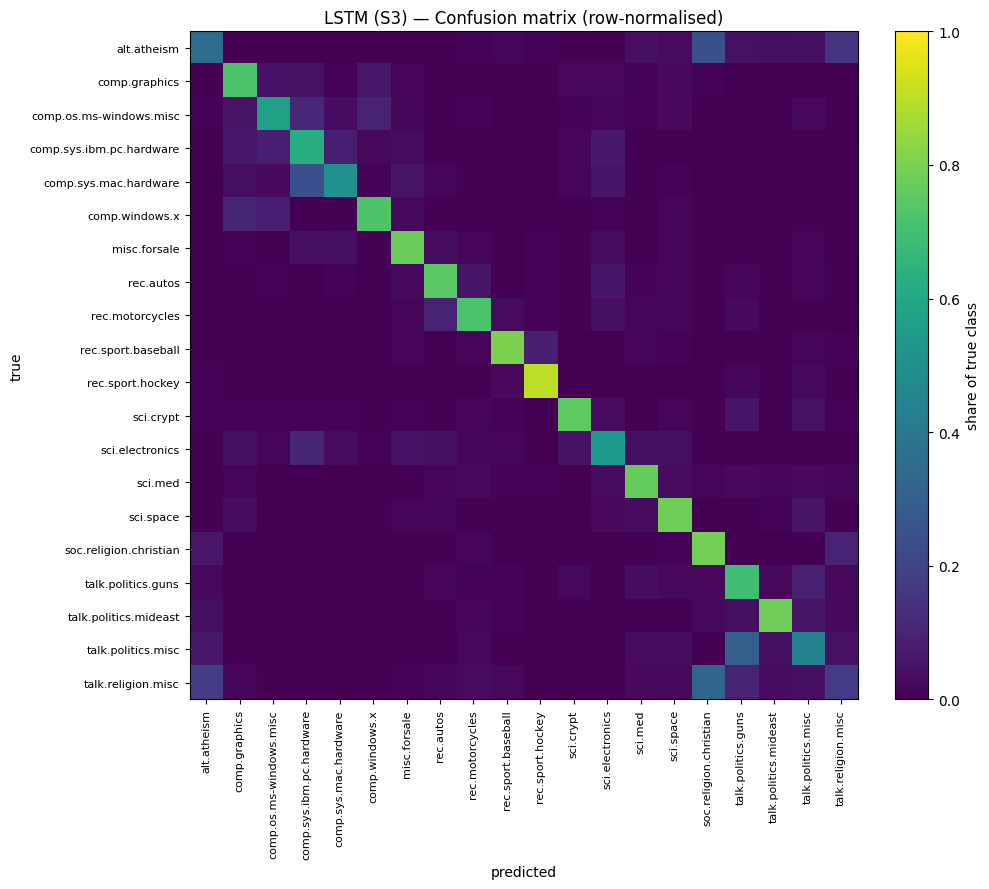

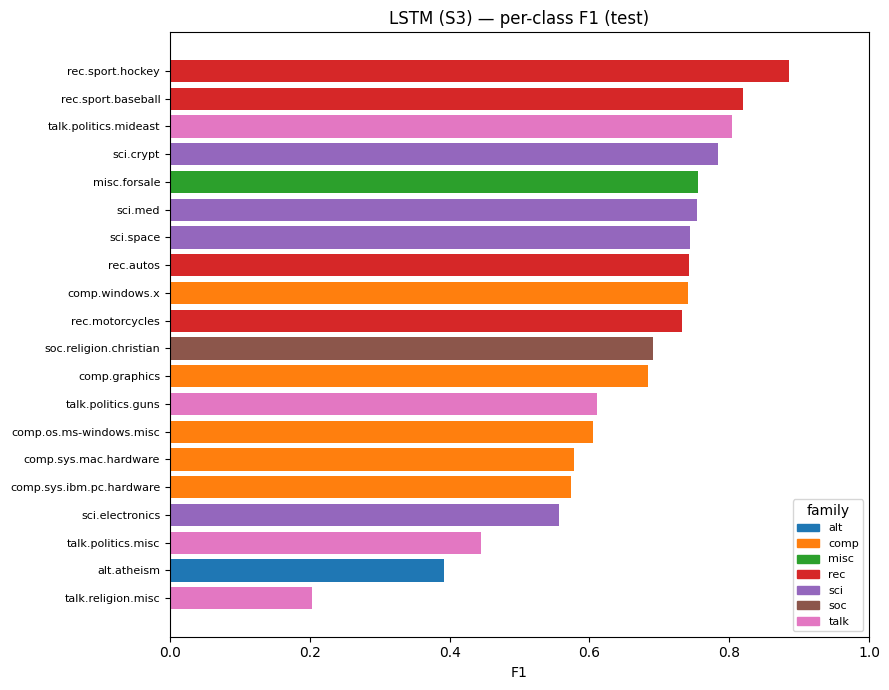

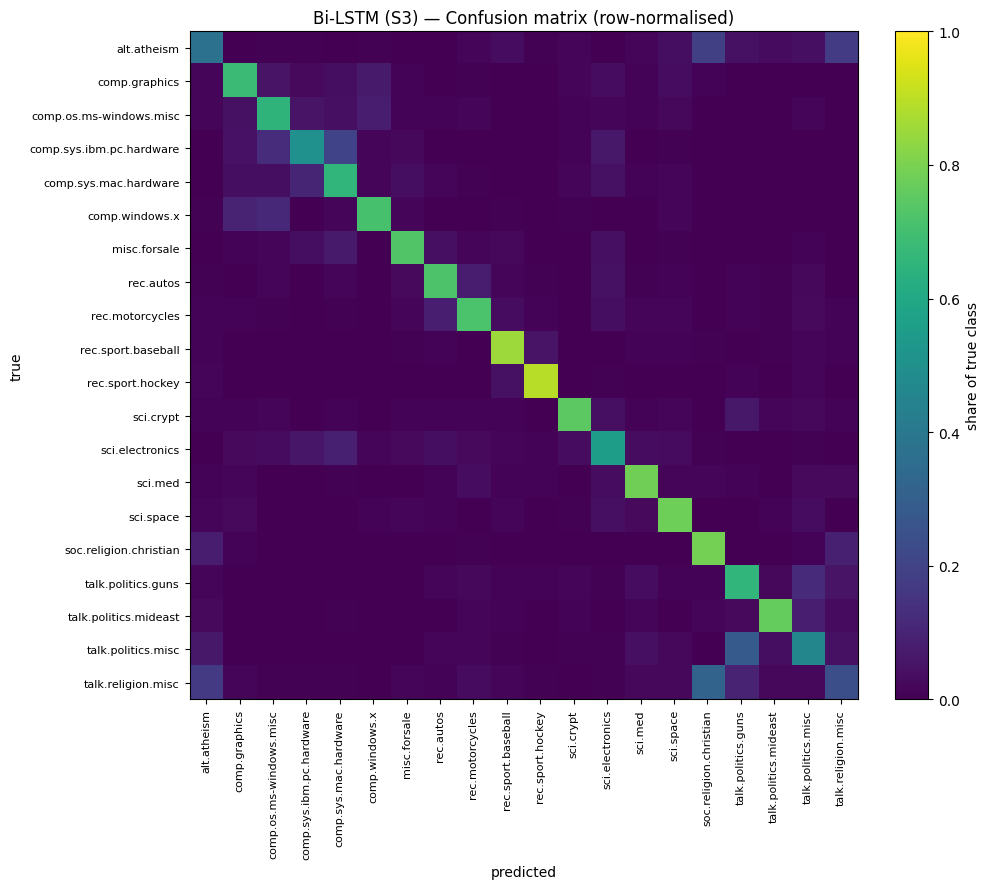

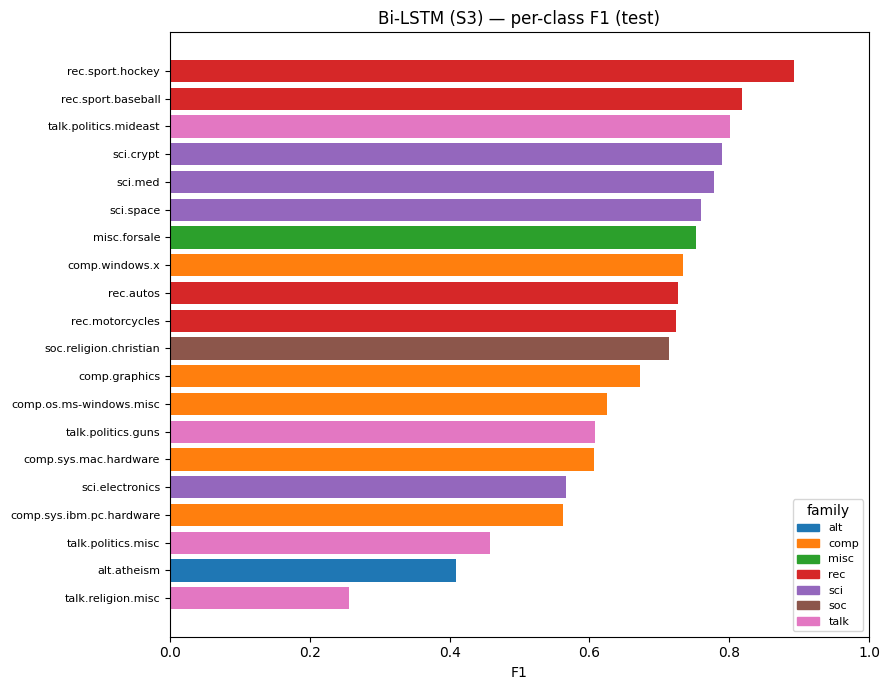

In [ ]:
for label, res in test_results.items():
    stem = label.replace(" ", "_").replace("(", "").replace(")", "")
    ev.plot_confusion_matrix(res, CLASS_NAMES,
                             save_path=FIG_DIR / f"cm_{stem}.png")
    plt.show()
    ev.plot_per_class_f1(res, save_path=FIG_DIR / f"f1_{stem}.png")
    plt.show()

In [ ]:
for label, res in test_results.items():
    print(f"\n{label} — five weakest classes")
    print(res["per_class"].head(5).to_string())
    print(f"\n{label} — five strongest classes")
    print(res["per_class"].tail(5).to_string())


LSTM (S3) — five weakest classes
                         family  precision  recall      f1  support
talk.religion.misc         talk     0.2389  0.1770  0.2033      243
alt.atheism                 alt     0.4481  0.3495  0.3927      309
talk.politics.misc         talk     0.4493  0.4404  0.4448      302
sci.electronics             sci     0.5742  0.5395  0.5563      380
comp.sys.ibm.pc.hardware   comp     0.5310  0.6250  0.5742      384

LSTM (S3) — five strongest classes
                      family  precision  recall      f1  support
misc.forsale            misc     0.7343  0.7772  0.7552      377
sci.crypt                sci     0.8161  0.7533  0.7834      377
talk.politics.mideast   talk     0.8290  0.7793  0.8034      367
rec.sport.baseball       rec     0.8384  0.8027  0.8202      375
rec.sport.hockey         rec     0.8706  0.9021  0.8861      388

Bi-LSTM (S3) — five weakest classes
                         family  precision  recall      f1  support
talk.religion.misc         

In [ ]:
best_label = comparison.iloc[0]["model"]
best_arch = best_label.split(" (")[0]
probs_best = MODELS[BEST[best_arch]].predict(X_test_seq, batch_size=256, verbose=0)

conf = ev.top_confusions(y_test, probs_best, CLASS_NAMES, SUPERCLASS, k=15)
print(f"{best_label} — 15 most frequent mistakes\n")
print(conf.to_string(index=False))
print(f"\nshare of these top-15 mistakes that stay inside one family: "
      f"{conf['same_family'].mean():.0%}")

Bi-LSTM (S3) — 15 most frequent mistakes

                    true                predicted  count  pct_of_true_class  same_family
      talk.politics.misc       talk.politics.guns     86             0.2848         True
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware     77             0.2005         True
      talk.religion.misc   soc.religion.christian     77             0.3169        False
             alt.atheism   soc.religion.christian     59             0.1909        False
             alt.atheism       talk.religion.misc     54             0.1748        False
comp.sys.ibm.pc.hardware  comp.os.ms-windows.misc     48             0.1250         True
          comp.windows.x  comp.os.ms-windows.misc     45             0.1154         True
      talk.politics.guns       talk.politics.misc     42             0.1197         True
      talk.religion.misc              alt.atheism     41             0.1687        False
          comp.windows.x            comp.graphics     38            

In [ ]:
pred_best = probs_best.argmax(axis=1)
correct = (pred_best == y_test)

tok_used = (X_test_seq != 0).sum(axis=1)
truncated = tok_used >= MAX_LEN

cuts = [c for c in (25, 50, 100, 175) if c < MAX_LEN - 1]
bins = [0] + cuts + [MAX_LEN - 1, MAX_LEN]
labels_ = ([f"<{cuts[0]}"]
           + [f"{a}-{b}" for a, b in zip(cuts, cuts[1:])]
           + [f"{cuts[-1]}-{MAX_LEN - 1}", "truncated"])
bucket = pd.cut(tok_used, bins=bins, labels=labels_, include_lowest=True)

by_len = pd.DataFrame({"bucket": bucket, "correct": correct}).groupby(
    "bucket", observed=False)["correct"].agg(["mean", "size"]).round(4)
by_len.columns = ["accuracy", "documents"]

print(f"{best_label} — accuracy by document length\n")
print(by_len.to_string())
print(f"\ntruncated documents : {truncated.sum():,} ({truncated.mean():.1%} of test)")
if truncated.any():
    acc_tr, acc_full = correct[truncated].mean(), correct[~truncated].mean()
    print(f"accuracy on truncated   : {acc_tr:.4f}")
    print(f"accuracy on complete    : {acc_full:.4f}")
    print(f"cost of the 250-token cap: {acc_full - acc_tr:+.4f}")
else:
    print("no document reached the cap — MAX_LEN is not binding on this split")

Bi-LSTM (S3) — accuracy by document length

           accuracy  documents
bucket                        
<25          0.5393       2251
25-50        0.6934       1918
50-100       0.7610       1653
100-175      0.7836        781
175-249      0.7750        240
truncated    0.7494        419

truncated documents : 419 (5.8% of test)
accuracy on truncated   : 0.7494
accuracy on complete    : 0.6722
cost of the 250-token cap: -0.0772


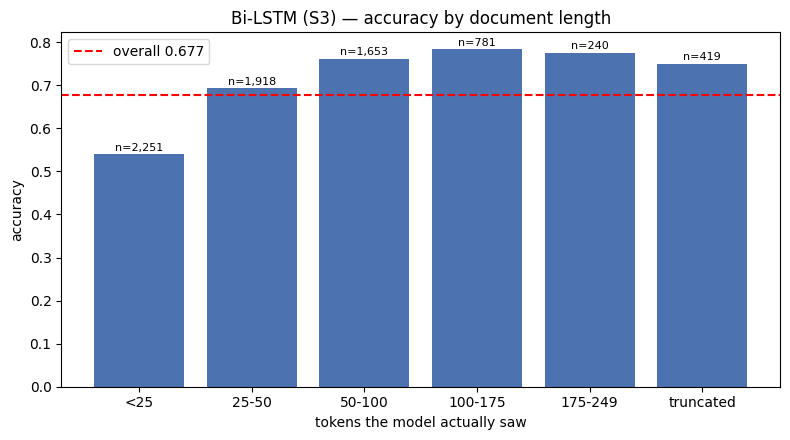

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(by_len.index.astype(str), by_len["accuracy"], color="#4c72b0")
ax.axhline(correct.mean(), color="red", ls="--",
           label=f"overall {correct.mean():.3f}")
ax.set_ylabel("accuracy"); ax.set_xlabel("tokens the model actually saw")
ax.set_title(f"{best_label} — accuracy by document length")
ax.legend()
for i, (a, n) in enumerate(zip(by_len["accuracy"], by_len["documents"])):
    ax.text(i, a + 0.008, f"n={n:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_accuracy_by_length.png", dpi=150)
plt.show()

In [ ]:
for label, res in test_results.items():
    f = res["family"]
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    print(f"errors        : {f['n_errors']:,} of {len(y_test):,}")
    print(f"within-family : {f['within_family']:,}  ({f['within_share']:.1%} of errors)")
    print(f"cross-family  : {f['cross_family']:,}  ({f['cross_share']:.1%} of errors)")
    print()
    print(f["per_family"].to_string())


LSTM (S3)
errors        : 2,382 of 7,262
within-family : 944  (39.6% of errors)
cross-family  : 1,438  (60.4% of errors)

        support  errors  error_rate  within_family  cross_family  pct_of_errors_within
family                                                                                
alt         309     201      0.6505              0           201                0.0000
comp       1904     703      0.3692            463           240                0.6586
misc        377      84      0.2228              0            84                0.0000
rec        1513     314      0.2075            126           188                0.4013
sci        1512     441      0.2917            110           331                0.2494
soc         384      81      0.2109              0            81                0.0000
talk       1263     558      0.4418            245           313                0.4391

Bi-LSTM (S3)
errors        : 2,348 of 7,262
within-family : 956  (40.7% of errors)
cross-fami

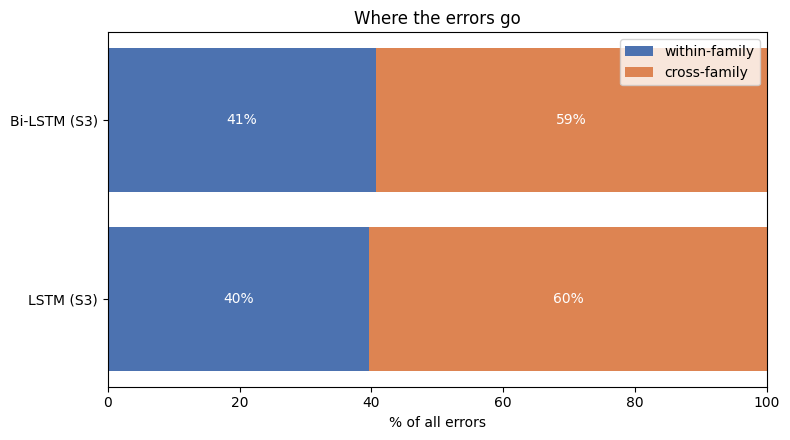

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels_list = list(test_results.keys())
within = [100 * test_results[l]["family"]["within_share"] for l in labels_list]
cross  = [100 * test_results[l]["family"]["cross_share"] for l in labels_list]

ax.barh(labels_list, within, label="within-family", color="#4c72b0")
ax.barh(labels_list, cross, left=within, label="cross-family", color="#dd8452")
ax.set_xlabel("% of all errors"); ax.set_xlim(0, 100)
ax.set_title("Where the errors go")
ax.legend()
for i, w in enumerate(within):
    ax.text(w / 2, i, f"{w:.0f}%", ha="center", va="center", color="white", fontsize=10)
    ax.text(w + (100 - w) / 2, i, f"{100-w:.0f}%", ha="center", va="center",
            color="white", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_family_error_split.png", dpi=150)
plt.show()

In [ ]:
for label, res in test_results.items():
    stem = "test_" + label.replace(" ", "_").replace("(", "").replace(")", "")
    p = ev.save_result(res, RESULTS_DIR, stem)
    print(f"saved {p.name}")

comparison.to_csv(RESULTS_DIR / "test_comparison_fabiha.csv", index=False)

final = pd.read_csv(RUNS_CSV)
print(f"\n{len(final)} runs logged in {RUNS_CSV.name}")
print(final[["run_id", "model", "config", "embedding", "val_accuracy",
             "val_macro_f1", "test_accuracy", "train_time_s"]].round(4).to_string(index=False))

print("\nfigures written:")
for p in sorted(FIG_DIR.glob("lstm_*.png")) + sorted(FIG_DIR.glob("cm_*.png")) + sorted(FIG_DIR.glob("f1_*.png")):
    print(f"  {p.name}")

saved test_LSTM_S3.json
saved test_Bi-LSTM_S3.json

8 runs logged in runs_fabiha.csv
    run_id   model    config embedding  val_accuracy  val_macro_f1  test_accuracy  train_time_s
 ABL_clean    LSTM ABL-clean     glove        0.6320        0.6219            NaN          79.5
 ABL_light    LSTM ABL-light     glove        0.6099        0.5889            NaN          73.3
   LSTM_S1    LSTM        S1     glove        0.6246        0.6120            NaN          76.1
   LSTM_S2    LSTM        S2  word2vec        0.6301        0.6094            NaN          78.6
   LSTM_S3    LSTM        S3  word2vec        0.7250        0.7122         0.6720          78.9
Bi-LSTM_S1 Bi-LSTM        S1     glove        0.6522        0.6378            NaN         113.9
Bi-LSTM_S2 Bi-LSTM        S2  word2vec        0.6320        0.6130            NaN          98.8
Bi-LSTM_S3 Bi-LSTM        S3  word2vec        0.7397        0.7283         0.6767         104.6

figures written:
  lstm_accuracy_by_length.png
  l

In [ ]:
MIGRATION_NOTE = ("outputs reorganised into results/fabiha/ and figures/fabiha/ after "
                  "the run; run schema migrated v1.0 -> v1.1 in place, no re-training")

assert len(ev.RUN_COLUMNS) == 26, (
    f"expected the v1.1 schema, got {len(ev.RUN_COLUMNS)} columns — re-run §1c "
    "so the updated utils/evaluation.py is published to Drive")

f = pd.read_csv(RUNS_CSV)
print(f"before : {len(f)} rows, {len(f.columns)} columns")
print(f"         {list(f.columns)}\n")

if "params" in f.columns and "n_params" not in f.columns:
    f = f.rename(columns={"params": "n_params"})

f["hyperparams"]      = ""
f["tier"]             = "recurrent"
f["dataset_checksum"] = DATASET_CHECKSUM

def normalise_note(run_id, note):
    """Prefix `notes` with a controlled token, idempotently.

    Any kind token already at the front is stripped first, so running this cell
    twice cannot stack `ablation ablation ...` — which matters because a
    top-to-bottom re-run of the notebook reaches this cell again.
    """
    body = "" if pd.isna(note) else str(note).strip()
    while body.split(" ")[0].lower() in ev.NOTE_KINDS:
        body = body[len(body.split(" ")[0]):].strip()
    body = body.replace("preprocessing ablation:", "preprocessing:")
    kind = "ablation" if str(run_id).startswith("ABL") else "required"
    return f"{kind} {body}".strip()


f["notes"] = [normalise_note(r, n) for r, n in zip(f["run_id"], f["notes"])]

f = f.reindex(columns=ev.RUN_COLUMNS)
f.to_csv(RUNS_CSV, index=False)

bad_tier = set(f["tier"]) - set(ev.TIERS)
bad_note = set(f["notes"].str.split(" ").str[0]) - set(ev.NOTE_KINDS)
assert not bad_tier, f"unexpected tier values: {bad_tier}"
assert not bad_note, f"notes must start with {ev.NOTE_KINDS}, found: {bad_note}"
assert f["dataset_checksum"].nunique() == 1, "rows disagree on dataset_checksum"

print(f"after  : {len(f)} rows, {len(f.columns)} columns  (schema v"
      f"{ev.SCORING_CONTRACT_VERSION})\n")
print(f[["run_id", "tier", "n_params", "epochs_run", "val_accuracy",
         "test_accuracy", "dataset_checksum", "notes"]].to_string(index=False))

before : 8 rows, 23 columns
         ['run_id', 'owner', 'notebook', 'model', 'config', 'embedding', 'units', 'dropout', 'trainable_emb', 'batch_size', 'learning_rate', 'epochs_run', 'best_epoch', 'params', 'val_loss', 'val_accuracy', 'val_macro_f1', 'train_time_s', 'timestamp', 'notes', 'test_accuracy', 'test_macro_f1', 'test_weighted_f1']

after  : 8 rows, 26 columns  (schema v1.1)

    run_id      tier  n_params  epochs_run  val_accuracy  test_accuracy     dataset_checksum                                              notes
 ABL_clean recurrent   1030740          30      0.631966            NaN 13885266476465583340 ablation preprocessing: text_clean (full strategy)
 ABL_light recurrent   1030740          30      0.609920            NaN 13885266476465583340                 ablation preprocessing: text_light
   LSTM_S1 recurrent   1030740          30      0.624617            NaN 13885266476465583340                                           required
   LSTM_S2 recurrent   1030740      